# Importing Libraries 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import json

from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import poisson

In [2]:
base_dir = Path('../artifacts')
PROCESSED_DIR = base_dir / 'processed_data'
MODEL_DIR = base_dir / 'models'
FIGURE_DIR = base_dir / 'figures'
FEATURE_DIR = base_dir / 'features'
METRICS_DIR     = base_dir / 'metrics'       
INTERIM_DIR     = base_dir / 'interim_data'  
PREDICTIONS_DIR = base_dir / 'predictions'



directories = [
    PROCESSED_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    FEATURE_DIR,
    METRICS_DIR,
    INTERIM_DIR,
    PREDICTIONS_DIR
]


for path in directories:
    path.mkdir(parents=True, exist_ok=True)
 

# Loading the Data

Let's load the dataset for poisson model. 

In [3]:
df = pd.read_csv(f'{PROCESSED_DIR}/poisson_features.csv', parse_dates=['date'])
print(df.shape)
print(df.dtypes)

(49233, 28)
date                         datetime64[us]
home_team                               str
away_team                               str
home_goals                          float64
away_goals                          float64
home_win                              int64
away_win                              int64
draw                                  int64
goal_diff                           float64
result                                int64
is_competitive                         bool
elo_diff                            float64
rank_diff                             int64
neutral                               int64
home_last5_goals_scored             float64
home_last5_goals_conceded           float64
away_last5_goals_scored             float64
away_last5_goals_conceded           float64
diff_last5_goals_scored             float64
diff_last5_goals_conceded           float64
home_last5_win_rate                 float64
away_last5_win_rate                 float64
home_h2h_win_rate   

In [4]:
df.head()

,date,home_team,away_team,home_goals,away_goals,home_win,away_win,draw,goal_diff,result,...,diff_last5_goals_scored,diff_last5_goals_conceded,home_last5_win_rate,away_last5_win_rate,home_h2h_win_rate,away_h2h_win_rate,home_h2h_goal_diff,home_is_host,away_is_host,home_tournament_stage
0,1872-11-30,Scotland,England,0.0,0.0,0,0,1,0.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,0,0
1,1873-03-08,England,Scotland,4.0,2.0,1,0,0,2.0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,0,0
2,1874-03-07,Scotland,England,2.0,1.0,1,0,0,1.0,0,...,-1.000000,1.000000,0.000000,0.500000,0.000000,0.500000,-2.0,0,0,0
3,1875-03-06,England,Scotland,2.0,2.0,0,0,1,0.0,1,...,0.333333,-0.333333,0.333333,0.333333,0.333333,0.333333,1.0,0,0,0
4,1876-03-04,Scotland,England,3.0,0.0,1,0,0,3.0,0,...,-0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,-1.0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49233 entries, 0 to 49232
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       49233 non-null  datetime64[us]
 1   home_team                  49233 non-null  str           
 2   away_team                  49233 non-null  str           
 3   home_goals                 49233 non-null  float64       
 4   away_goals                 49233 non-null  float64       
 5   home_win                   49233 non-null  int64         
 6   away_win                   49233 non-null  int64         
 7   draw                       49233 non-null  int64         
 8   goal_diff                  49233 non-null  float64       
 9   result                     49233 non-null  int64         
 10  is_competitive             49233 non-null  bool          
 11  elo_diff                   49233 non-null  float64       
 12  rank_diff      

# Feature Columns 

In [6]:
META_COLS   = ['date', 'home_team', 'away_team']
TARGET_COLS = ['home_goals', 'away_goals', 'home_win', 'draw', 'away_win', 'result']
 
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]
print(f"\nFeatures used: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features used: 19
['goal_diff', 'is_competitive', 'elo_diff', 'rank_diff', 'neutral', 'home_last5_goals_scored', 'home_last5_goals_conceded', 'away_last5_goals_scored', 'away_last5_goals_conceded', 'diff_last5_goals_scored', 'diff_last5_goals_conceded', 'home_last5_win_rate', 'away_last5_win_rate', 'home_h2h_win_rate', 'away_h2h_win_rate', 'home_h2h_goal_diff', 'home_is_host', 'away_is_host', 'home_tournament_stage']


# Train / Valid Split 

There are many changes happened in the game after 2000  so we are just taking dataset from 2000 so that data is not biased. We are filtering the matches which are competitive. 

In [7]:
if 'is_competitive' not in df.columns:
    df['is_competitive'] = True
 
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()
 
train = train_df[train_df['date'] <  '2024-01-01'].copy()
valid = train_df[train_df['date'] >= '2024-01-01'].copy()
 
print(f"\nTrain : {len(train):,} matches  ({train['date'].dt.year.min()}–{train['date'].dt.year.max()})")
print(f"Valid : {len(valid):,} matches  ({valid['date'].dt.year.min()}–{valid['date'].dt.year.max()})")


Train : 14,855 matches  (2000–2023)
Valid : 1,776 matches  (2024–2026)


In [8]:
X_train = train[FEATURE_COLS].fillna(0)
X_valid = valid[FEATURE_COLS].fillna(0)
 
y_train_home = train['home_goals']
y_train_away = train['away_goals']
y_valid_home = valid['home_goals']
y_valid_away = valid['away_goals']

# Scaling the Data

In [9]:
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_valid_scaled = scaler.transform(X_valid) 

# Training the models

In [10]:
model_home = PoissonRegressor(alpha=0.1, max_iter=1000)
model_away = PoissonRegressor(alpha=0.1, max_iter=1000)
 
model_home.fit(X_train_scaled, y_train_home)
model_away.fit(X_train_scaled, y_train_away)
 
print("\nModels trained.")
print(f"  Home model iterations: {model_home.n_iter_}")
print(f"  Away model iterations: {model_away.n_iter_}")


Models trained.
  Home model iterations: 17
  Away model iterations: 15


# Predicting on Validation set 

In [11]:
valid = valid.copy()
valid['pred_home_goals'] = model_home.predict(X_valid_scaled)   # λ_home
valid['pred_away_goals'] = model_away.predict(X_valid_scaled)   # λ_away
 
print("\nSample predictions:")
print(valid[['date','home_team','away_team',
             'home_goals','pred_home_goals',
             'away_goals','pred_away_goals']].head(10).to_string(index=False))


Sample predictions:
      date            home_team         away_team  home_goals  pred_home_goals  away_goals  pred_away_goals
2024-01-12                Qatar           Lebanon         3.0         2.712760         0.0         0.417154
2024-01-13                China        Tajikistan         0.0         1.484839         0.0         0.993322
2024-01-13            Australia             India         2.0         2.240376         0.0         0.522354
2024-01-13           Uzbekistan             Syria         0.0         1.374372         0.0         0.955423
2024-01-13          Ivory Coast     Guinea-Bissau         2.0         1.762494         0.0         0.602983
2024-01-14              Nigeria Equatorial Guinea         1.0         1.534184         1.0         0.940817
2024-01-14                Japan           Vietnam         4.0         2.165327         2.0         0.549278
2024-01-14                Egypt        Mozambique         2.0         1.657928         2.0         0.871526
2024-01

# Goal Prediction Metrics

In [12]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
mae_home  = mean_absolute_error(y_valid_home, valid['pred_home_goals'])
mae_away  = mean_absolute_error(y_valid_away, valid['pred_away_goals'])
rmse_home = rmse(y_valid_home, valid['pred_home_goals'])
rmse_away = rmse(y_valid_away, valid['pred_away_goals'])
 
print("\n Goal Prediction Metrics ")
print(f"  Home goals  →  MAE: {mae_home:.4f}  |  RMSE: {rmse_home:.4f}")
print(f"  Away goals  →  MAE: {mae_away:.4f}  |  RMSE: {rmse_away:.4f}")
 
# Baseline comparison: always predict the training mean
baseline_home = np.full(len(valid), y_train_home.mean())
baseline_away = np.full(len(valid), y_train_away.mean())
 
print("\n Baseline (always predict training mean)")
print(f"  Home goals  →  MAE: {mean_absolute_error(y_valid_home, baseline_home):.4f}  |  RMSE: {rmse(y_valid_home, baseline_home):.4f}")
print(f"  Away goals  →  MAE: {mean_absolute_error(y_valid_away, baseline_away):.4f}  |  RMSE: {rmse(y_valid_away, baseline_away):.4f}")


 Goal Prediction Metrics 
  Home goals  →  MAE: 0.7380  |  RMSE: 0.9141
  Away goals  →  MAE: 0.6426  |  RMSE: 0.8125

 Baseline (always predict training mean)
  Home goals  →  MAE: 1.2397  |  RMSE: 1.5768
  Away goals  →  MAE: 0.9799  |  RMSE: 1.3234


# Scatter — Predicted vs Actual Goals

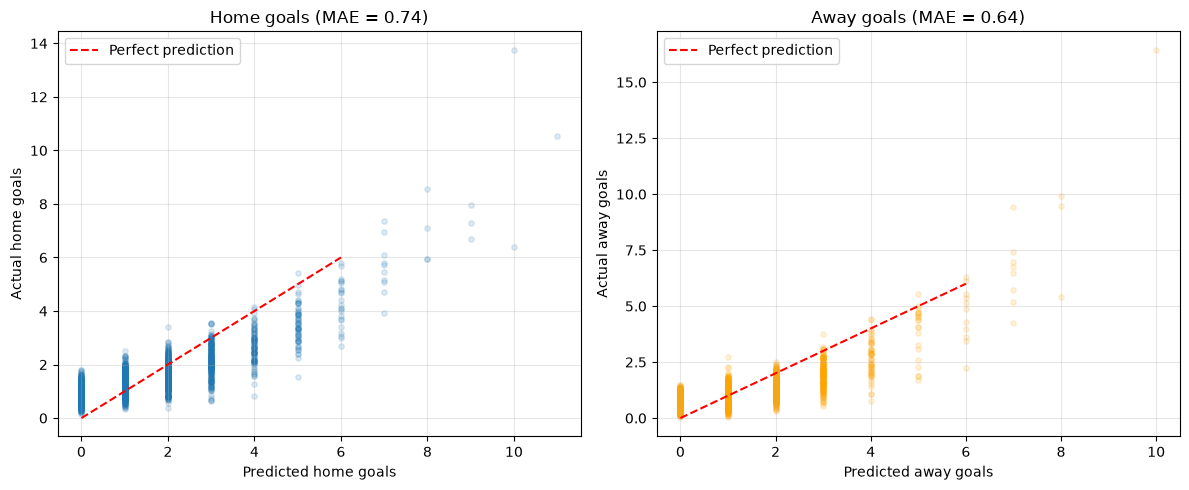

In [13]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home goals
axes[0].scatter(y_valid_home, valid['pred_home_goals'], alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Predicted home goals')
axes[0].set_ylabel('Actual home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Away goals
axes[1].scatter(y_valid_away, valid['pred_away_goals'], alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Predicted away goals')
axes[1].set_ylabel('Actual away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Outcome Evaluation 

In [14]:
def predict_outcome(p_home: float, p_draw: float, p_away: float,
                    draw_threshold: float = 0.28) -> int:
    """
    0 = Home Win, 1 = Draw, 2 = Away Win
    If draw probability exceeds threshold → predict draw.
    Otherwise take argmax of home/away.
    """
    if p_draw >= draw_threshold:
        return 1
    return 0 if p_home >= p_away else 2

In [15]:

def evaluate_outcome(valid: pd.DataFrame, draw_threshold: float = 0.28) -> None:
    """Full evaluation block: accuracy + confusion matrix + classification report."""

    valid = valid.copy()
    valid['pred_result'] = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'],
            draw_threshold
        ), axis=1
    )

    accuracy = (valid['pred_result'] == valid['result']).mean()
    print(f"\n Outcome Accuracy (draw_threshold={draw_threshold:.2f}) ")
    print(f"  Correct outcome predicted: {accuracy:.2%}")

    cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
    print("\n Confusion Matrix (rows=actual, cols=predicted)")
    print(pd.DataFrame(
        cm,
        index  =['Actual HW', 'Actual Draw', 'Actual AW'],
        columns=['Pred HW',   'Pred Draw',   'Pred AW']
    ))

    print("\n Classification Report ")
    print(classification_report(
        valid['result'], valid['pred_result'],
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        zero_division=0
    ))


# Deriving Win / Draw / Loss

In [16]:
MAX_GOALS = 10 
 
def score_grid_probabilities(lambda_home: float, lambda_away: float):
    """
    Returns (p_home_win, p_draw, p_away_win) by summing over all
    score combinations up to MAX_GOALS × MAX_GOALS.
    """

    p_home = np.array([poisson.pmf(i, lambda_home) for i in range(MAX_GOALS)])
    p_away = np.array([poisson.pmf(i, lambda_away) for i in range(MAX_GOALS)])
    grid   = np.outer(p_home, p_away)   # [i,j] = P(home=i, away=j)
 
    p_home_win = np.tril(grid, k=-1).sum()   # home goals > away goals
    p_draw     = np.trace(grid)               # home goals == away goals
    p_away_win = np.triu(grid, k=1).sum()    # away goals > home goals
 
    return p_home_win, p_draw, p_away_win
 
 
probs = valid.apply(
    lambda r: score_grid_probabilities(r['pred_home_goals'], r['pred_away_goals']),
    axis=1, result_type='expand'
)
probs.columns = ['prob_home_win', 'prob_draw', 'prob_away_win']
valid = pd.concat([valid, probs], axis=1)

# Evaluation 

Baseline evaluation using argmax predicts whichever outcome has the highest probability. Establishes the starting accuracy before draw threshold tuning. Expected to miss most draws since draw probability is rarely the argmax.

In [17]:

print("=" * 60)
print("DEFAULT: argmax ")
print("=" * 60)

valid['pred_result'] = valid[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1)
valid['pred_result'] = valid['pred_result'].map({
    'prob_home_win': 0,
    'prob_draw':     1,
    'prob_away_win': 2,
})

accuracy = (valid['pred_result'] == valid['result']).mean()
print(f"\n  Correct outcome predicted: {accuracy:.2%}")
 
cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
print("\n Confusion Matrix ")
print(pd.DataFrame(
    cm,
    index  =['Actual HW', 'Actual Draw', 'Actual AW'],
    columns=['Pred HW',   'Pred Draw',   'Pred AW']
))
print("\n Classification Report ")
print(classification_report(
    valid['result'], valid['pred_result'],
    target_names=['HomeWin', 'Draw', 'AwayWin'],
    zero_division=0
))

DEFAULT: argmax 

  Correct outcome predicted: 74.16%

 Confusion Matrix 
             Pred HW  Pred Draw  Pred AW
Actual HW        817          0        8
Actual Draw      284          0      129
Actual AW         38          0      500

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.72      0.99      0.83       825
        Draw       0.00      0.00      0.00       413
     AwayWin       0.78      0.93      0.85       538

    accuracy                           0.74      1776
   macro avg       0.50      0.64      0.56      1776
weighted avg       0.57      0.74      0.64      1776



In [18]:
print("\n" + "=" * 60)
print("TUNING: Find best draw threshold")
print("=" * 60)

thresholds  = np.arange(0.20, 0.45, 0.01)
results     = []

for thresh in thresholds:
    preds = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh
        ), axis=1
    )
    acc        = (preds == valid['result']).mean()
    draw_rate  = (preds == 1).mean()
    results.append({
        'threshold':       round(thresh, 2),
        'accuracy':        round(acc, 4),
        'pred_draw_rate':  round(draw_rate, 4),
    })

df_thresh = pd.DataFrame(results)

best_row   = df_thresh.loc[df_thresh['accuracy'].idxmax()]
best_thresh = best_row['threshold']
best_acc    = best_row['accuracy']

print(f"\n  Actual draw rate in validation : {(valid['result'] == 1).mean():.2%}")
print(f"\n  Best threshold : {best_thresh:.2f}")
print(f"  Best accuracy  : {best_acc:.2%}")
print(f"\n  Threshold scan:")
print(df_thresh.to_string(index=False))


TUNING: Find best draw threshold

  Actual draw rate in validation : 23.25%

  Best threshold : 0.28
  Best accuracy  : 81.02%

  Threshold scan:
 threshold  accuracy  pred_draw_rate
      0.20    0.5709          0.6605
      0.21    0.6059          0.6256
      0.22    0.6413          0.5901
      0.23    0.6757          0.5524
      0.24    0.7117          0.5118
      0.25    0.7432          0.4611
      0.26    0.7776          0.3986
      0.27    0.8041          0.3097
      0.28    0.8102          0.1819
      0.29    0.7590          0.0462
      0.30    0.7432          0.0039
      0.31    0.7416          0.0000
      0.32    0.7416          0.0000
      0.33    0.7416          0.0000
      0.34    0.7416          0.0000
      0.35    0.7416          0.0000
      0.36    0.7416          0.0000
      0.37    0.7416          0.0000
      0.38    0.7416          0.0000
      0.39    0.7416          0.0000
      0.40    0.7416          0.0000
      0.41    0.7416          0.0000
  

# Threshold tuning plot

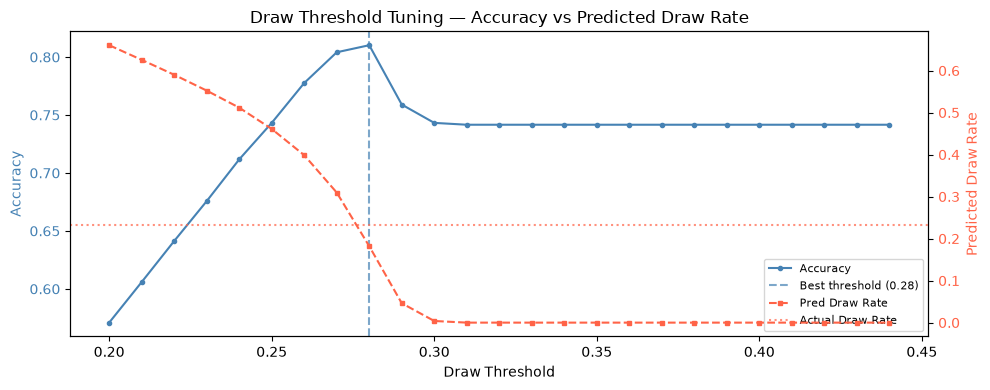

In [19]:

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df_thresh['threshold'], df_thresh['accuracy'],
         color='steelblue', marker='o', markersize=3, label='Accuracy')
ax1.axvline(best_thresh, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Best threshold ({best_thresh:.2f})')
ax1.set_xlabel('Draw Threshold')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['pred_draw_rate'],
         color='tomato', marker='s', markersize=3, linestyle='--', label='Pred Draw Rate')
ax2.axhline((valid['result'] == 1).mean(), color='tomato', linestyle=':',
            alpha=0.7, label='Actual Draw Rate')
ax2.set_ylabel('Predicted Draw Rate', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

plt.title('Draw Threshold Tuning — Accuracy vs Predicted Draw Rate')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/poisson_threshold_tuning.png', dpi=150)
plt.show()




# Final evaluation with best threshold

In [20]:

print("\n" + "=" * 60)
print(f"FINAL EVALUATION — draw_threshold = {best_thresh:.2f}")
print("=" * 60)

evaluate_outcome(valid, draw_threshold=best_thresh)


FINAL EVALUATION — draw_threshold = 0.28

 Outcome Accuracy (draw_threshold=0.28) 
  Correct outcome predicted: 81.02%

 Confusion Matrix (rows=actual, cols=predicted)
             Pred HW  Pred Draw  Pred AW
Actual HW        769         55        1
Actual Draw      164        210       39
Actual AW         20         58      460

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.81      0.93      0.87       825
        Draw       0.65      0.51      0.57       413
     AwayWin       0.92      0.86      0.89       538

    accuracy                           0.81      1776
   macro avg       0.79      0.77      0.77      1776
weighted avg       0.80      0.81      0.80      1776



With the best threshold we are able to improve the accuracy to 81.02 % 

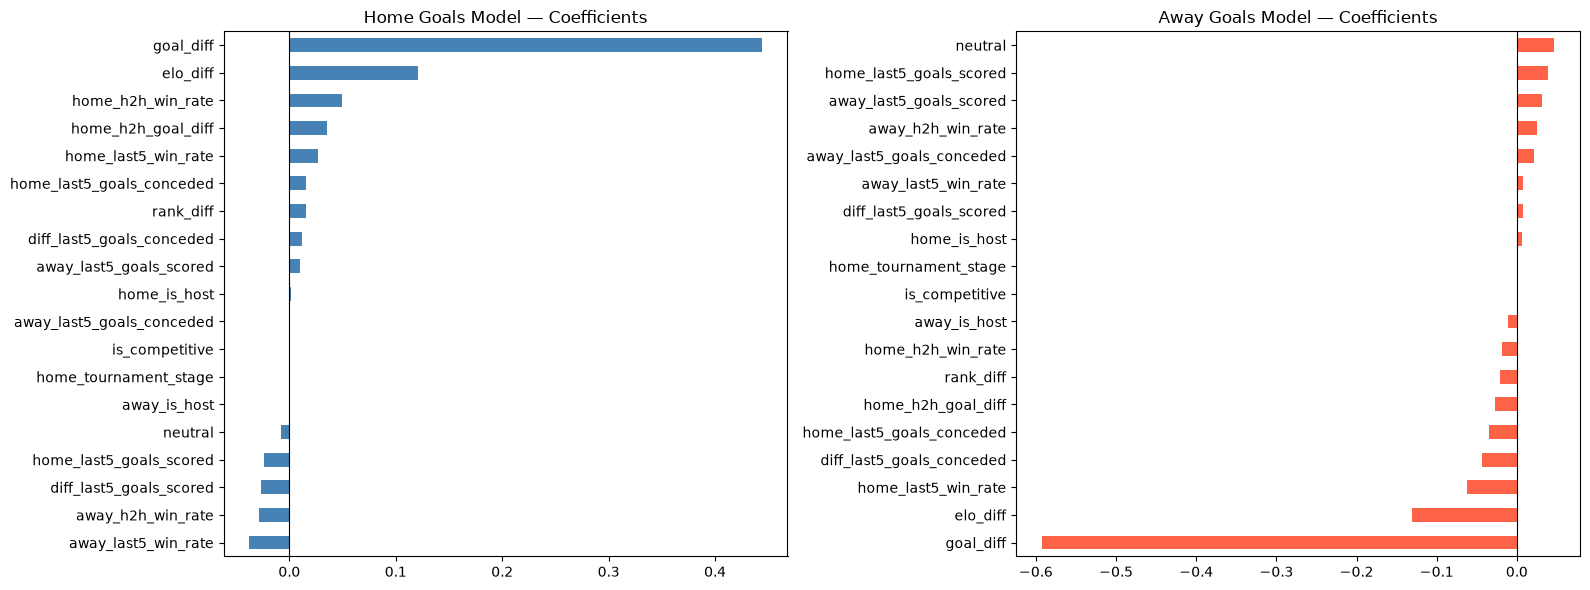

In [21]:
 
coef_home = pd.Series(model_home.coef_, index=FEATURE_COLS).sort_values()
coef_away = pd.Series(model_away.coef_, index=FEATURE_COLS).sort_values()
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
coef_home.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Home Goals Model — Coefficients')
axes[0].axvline(0, color='black', linewidth=0.8)
 
coef_away.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Away Goals Model — Coefficients')
axes[1].axvline(0, color='black', linewidth=0.8)
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/poisson_coefficients.png', dpi=150)
plt.show()

# Goal Distribution

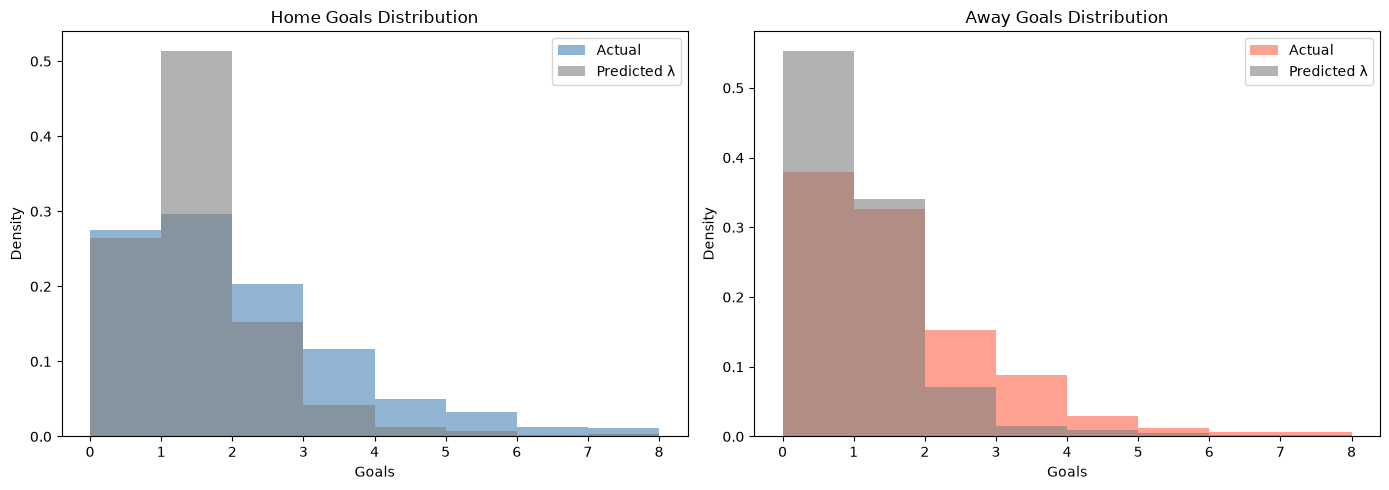

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col_actual, col_pred, title, color in [
    (axes[0], 'home_goals', 'pred_home_goals', 'Home Goals', 'steelblue'),
    (axes[1], 'away_goals', 'pred_away_goals', 'Away Goals', 'tomato'),
]:
    ax.hist(valid[col_actual].clip(0, 7), bins=range(9),
            alpha=0.6, label='Actual', color=color, density=True)
    ax.hist(valid[col_pred].clip(0, 7), bins=range(9),
            alpha=0.6, label='Predicted λ', color='gray', density=True)
    ax.set_title(f'{title} Distribution')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Density')
    ax.legend()
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/poisson_goal_distribution.png', dpi=150)
plt.show()

# Saving the Model 

In [23]:
joblib.dump(model_home, f'{MODEL_DIR}/poisson_home.pkl')
joblib.dump(model_away, f'{MODEL_DIR}/poisson_away.pkl')
joblib.dump(scaler,     f'{MODEL_DIR}/poisson_scaler.pkl')

pd.Series(FEATURE_COLS).to_csv(f'{FEATURE_DIR}/poisson_feature_cols.csv', index=False)

#  Save threshold config 
thresh_cfg = {
    'draw_threshold':      float(best_thresh),
    'validation_accuracy': float(best_acc),
    'actual_draw_rate':    round((valid['result'] == 1).mean(), 4),

}
with open(f'{METRICS_DIR}/poisson_threshold.json', 'w') as f:
    json.dump(thresh_cfg, f, indent=2)

#  Save validation predictions 
valid.to_csv(f'{PREDICTIONS_DIR}/poisson_valid_preds.csv', index=False)

print("\nSaved:")
print(f"  models/      → poisson_home.pkl")
print(f"  models/      → poisson_away.pkl")
print(f"  models/      → poisson_scaler.pkl")
print(f"  features/    → poisson_feature_cols.csv")
print(f"  metrics/     → poisson_threshold.json")
print(f"  predictions/ → poisson_valid_preds.csv")
print(json.dumps(thresh_cfg, indent=2))


Saved:
  models/      → poisson_home.pkl
  models/      → poisson_away.pkl
  models/      → poisson_scaler.pkl
  features/    → poisson_feature_cols.csv
  metrics/     → poisson_threshold.json
  predictions/ → poisson_valid_preds.csv
{
  "draw_threshold": 0.28,
  "validation_accuracy": 0.8102,
  "actual_draw_rate": 0.2325
}


# Retrain Final Model on Full 2000-2025 Data

In [24]:

# Evaluation models above stay unchanged for metric comparison.
# Final models below are trained on all available data for
# tournament simulation — more recent form, better predictions.

print("\nRetraining final Poisson model on full 2000-2025 data...")

# Load full dataset
df_full = pd.read_csv(f'{PROCESSED_DIR}/poisson_features.csv',
                       parse_dates=['date'])

train_final = df_full[
    df_full['is_competitive'] &
    (df_full['date'] >= '2000-01-01') &
    (df_full['date'] <  '2026-01-01')
].copy()

print(f"Final train: {len(train_final):,} matches "
      f"({train_final['date'].dt.year.min()}–"
      f"{train_final['date'].dt.year.max()})")

X_final       = train_final[FEATURE_COLS].fillna(0)
y_final_home  = train_final['home_goals']
y_final_away  = train_final['away_goals']

# Same scaler — refit on full data
scaler_final  = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

# Same hyperparameters as evaluation model
model_home_final = PoissonRegressor(alpha=0.1, max_iter=1000)
model_away_final = PoissonRegressor(alpha=0.1, max_iter=1000)

model_home_final.fit(X_final_scaled, y_final_home)
model_away_final.fit(X_final_scaled, y_final_away)

print(f"  Home model iterations: {model_home_final.n_iter_}")
print(f"  Away model iterations: {model_away_final.n_iter_}")

# Save final models separately
joblib.dump(model_home_final, f'{MODEL_DIR}/poisson_home_final.pkl')
joblib.dump(model_away_final, f'{MODEL_DIR}/poisson_away_final.pkl')
joblib.dump(scaler_final,     f'{MODEL_DIR}/poisson_scaler_final.pkl')

print("\nFinal models saved:")
print(f"  models/ → poisson_home_final.pkl")
print(f"  models/ → poisson_away_final.pkl")
print(f"  models/ → poisson_scaler_final.pkl")



Retraining final Poisson model on full 2000-2025 data...
Final train: 16,577 matches (2000–2025)
  Home model iterations: 17
  Away model iterations: 15

Final models saved:
  models/ → poisson_home_final.pkl
  models/ → poisson_away_final.pkl
  models/ → poisson_scaler_final.pkl
